# Task 1: Netflix Data Cleaning & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("Dataset.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
# Display first 5 rows
display(df.head())

# Display last 5 rows
display(df.tail())

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
display(df.describe(include="all").T)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


Dataset Shape: (8790, 10)

Columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s8786,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8787,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8790,4528,Not Given,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8790,86,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,1/1/2020,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_values)

,Missing Count,Missing Percentage
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0
listed_in,0,0.0


In [ ]:
# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Check duplicate show IDs
print("Duplicate Show IDs:", df["show_id"].duplicated().sum())

# Remove duplicate show IDs if any
df = df.drop_duplicates(subset=["show_id"], keep="first")

print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 0
Duplicate Show IDs: 0
Shape After Removing Duplicates: (8790, 10)


In [ ]:
# Fill missing categorical values
columns_to_fill = [
    "director",
    "cast",
    "country",
    "rating",
    "listed_in"
]

for col in columns_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Remove records without essential title/type
df = df.dropna(subset=["title", "type"])

print("Missing values handled successfully!")

display(df.isnull().sum())

Missing values handled successfully!


,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Clean text columns
text_columns = df.select_dtypes(include=["object", "string"]).columns

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()
    df[col] = df[col].str.replace(r"\s+", " ", regex=True)

# Standardize content type
df["type"] = df["type"].str.title()

print("Text cleaning completed!")

display(df.head())

Text cleaning completed!


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,Tv Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
# Convert date_added into datetime format
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

print("Date conversion completed!")

print(df["date_added"].dtype)

display(df[["title", "date_added"]].head(10))

Date conversion completed!
datetime64[ns]


,title,date_added
0,Dick Johnson Is Dead,2021-09-25
1,Ganglands,2021-09-24
2,Midnight Mass,2021-09-24
3,Confessions of an Invisible Girl,2021-09-22
4,Sankofa,2021-09-24
5,The Great British Baking Show,2021-09-24
6,The Starling,2021-09-24
7,Motu Patlu in the Game of Zones,2021-05-01
8,Je Suis Karl,2021-09-23
9,Motu Patlu in Wonderland,2021-05-01


In [ ]:
# Extract numeric duration
df["duration_value"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
).astype("Int64")

# Extract duration unit
df["duration_unit"] = (
    df["duration"]
    .str.extract(r"\d+\s*(.*)")[0]
    .str.strip()
    .str.lower()
)

print("Duration transformation completed!")

display(
    df[["title", "duration", "duration_value", "duration_unit"]].head(10)
)

Duration transformation completed!


,title,duration,duration_value,duration_unit
0,Dick Johnson Is Dead,90 min,90,min
1,Ganglands,1 Season,1,season
2,Midnight Mass,1 Season,1,season
3,Confessions of an Invisible Girl,91 min,91,min
4,Sankofa,125 min,125,min
5,The Great British Baking Show,9 Seasons,9,seasons
6,The Starling,104 min,104,min
7,Motu Patlu in the Game of Zones,87 min,87,min
8,Je Suis Karl,127 min,127,min
9,Motu Patlu in Wonderland,76 min,76,min


In [ ]:
print("========== FINAL DATASET REPORT ==========")

print("\nDataset Shape:", df.shape)

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nData Types:")
display(df.dtypes)

print("\nFinal Dataset Preview:")
display(df.head(10))

========== FINAL DATASET REPORT ==========

Dataset Shape: (8790, 12)

Duplicate Rows: 0

Missing Values:


,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0



Data Types:


,0
show_id,string[python]
type,string[python]
title,string[python]
director,string[python]
country,string[python]
date_added,datetime64[ns]
release_year,int64
rating,string[python]
duration,string[python]
listed_in,string[python]



Final Dataset Preview:


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min
5,s9,Tv Show,The Great British Baking Show,Andy Devonshire,United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",9,seasons
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",104,min
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu...",87,min
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",127,min
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,2021-05-01,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals",76,min


In [ ]:
df.to_csv("netflix_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")
print("File Name: netflix_cleaned.csv")

Cleaned dataset exported successfully!
File Name: netflix_cleaned.csv


# Task 2: Netflix Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv("netflix_cleaned.csv")

print("Dataset loaded successfully!")

display(df.head())

Dataset loaded successfully!


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
print("Dataset Shape:", df.shape)

print("\nTotal Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (8790, 12)

Total Rows: 8790
Total Columns: 12

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'duration_value', 'duration_unit']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8790 non-null   object
 1   type            8790 non-null   object
 2   title           8790 non-null   object
 3   director        8790 non-null   object
 4   country         8790 non-null   object
 5   date_added      8790 non-null   object
 6   release_year    8790 non-null   int64 
 7   rating          8790 non-null   object
 8   duration        8790 non-null   object
 9   listed_in       8790 non-null   object
 10  duration_value  8790 non-null   int64 
 11  duration_unit   8790 non-null   object
dtypes: int64(2), object(1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s8786,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8786,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8790,4528,Not Given,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8790,86,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,2020-01-01,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

display(missing.sort_values(
    by="Missing Values",
    ascending=False
))

,Missing Values,Percentage
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0
listed_in,0,0.0


In [ ]:
type_counts = df["type"].value_counts()

print("Content Distribution:")
display(type_counts.to_frame("Count"))

print("\nPercentage Distribution:")
display(
    (df["type"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("Percentage")
)

Content Distribution:


,Count
type,
Movie,6126
Tv Show,2664



Percentage Distribution:


,Percentage
type,
Movie,69.69
Tv Show,30.31


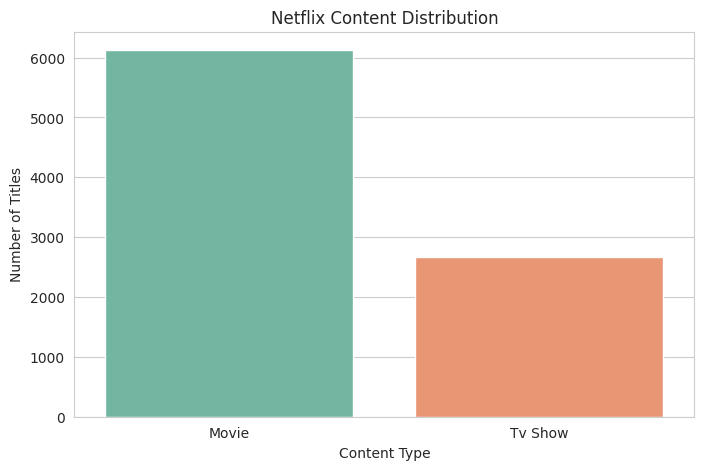

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Netflix Content Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

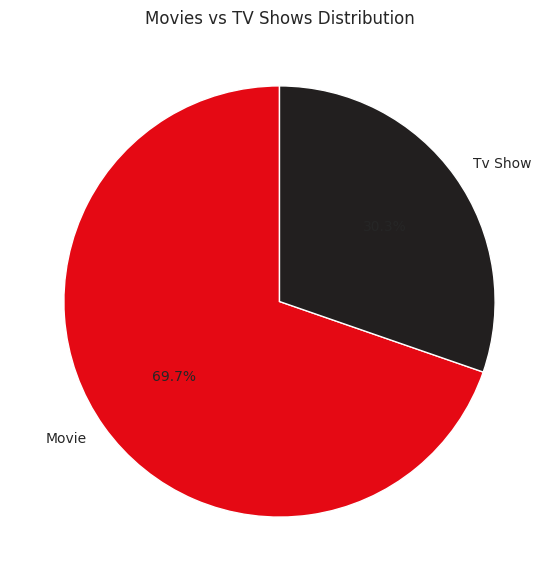

In [ ]:
plt.figure(figsize=(7, 7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#E50914", "#221F1F"]
)

plt.title("Movies vs TV Shows Distribution")

plt.show()

In [ ]:
country_data = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

country_data = country_data[
    ~country_data.str.lower().isin(["unknown", "", "nan"])
]

top_countries = country_data.value_counts().head(10)

print("Top 10 Countries:")
display(top_countries.to_frame("Number of Titles"))

Top 10 Countries:


,Number of Titles
country,
United States,3240
India,1057
United Kingdom,638
Pakistan,421
Not Given,287
Canada,271
Japan,259
South Korea,214
France,213


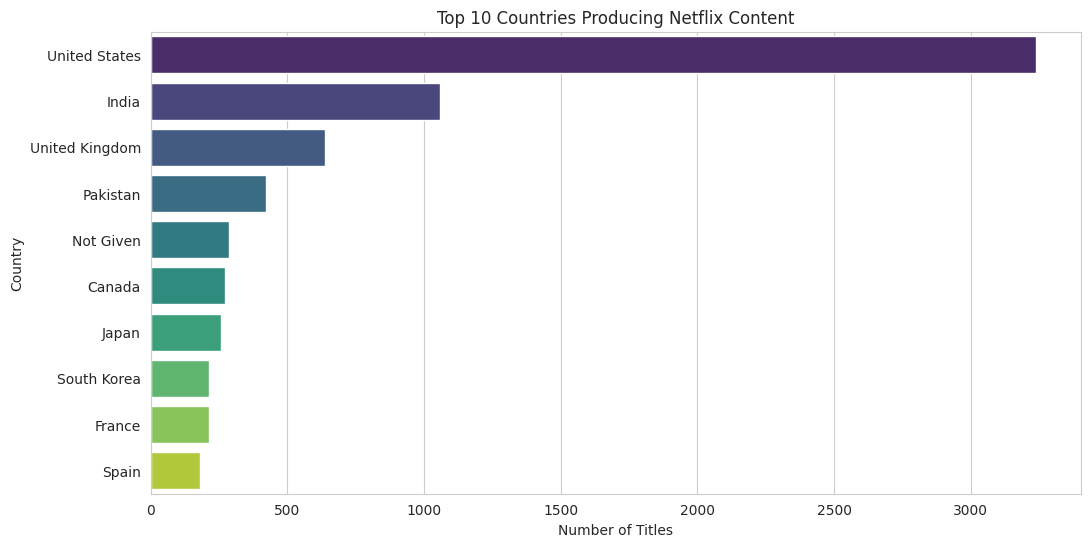

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [ ]:
genre_data = (
    df["listed_in"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

genre_data = genre_data[
    ~genre_data.str.lower().isin(["unknown", "", "nan"])
]

top_genres = genre_data.value_counts().head(10)

print("Top 10 Netflix Categories:")
display(top_genres.to_frame("Number of Titles"))

Top 10 Netflix Categories:


,Number of Titles
listed_in,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


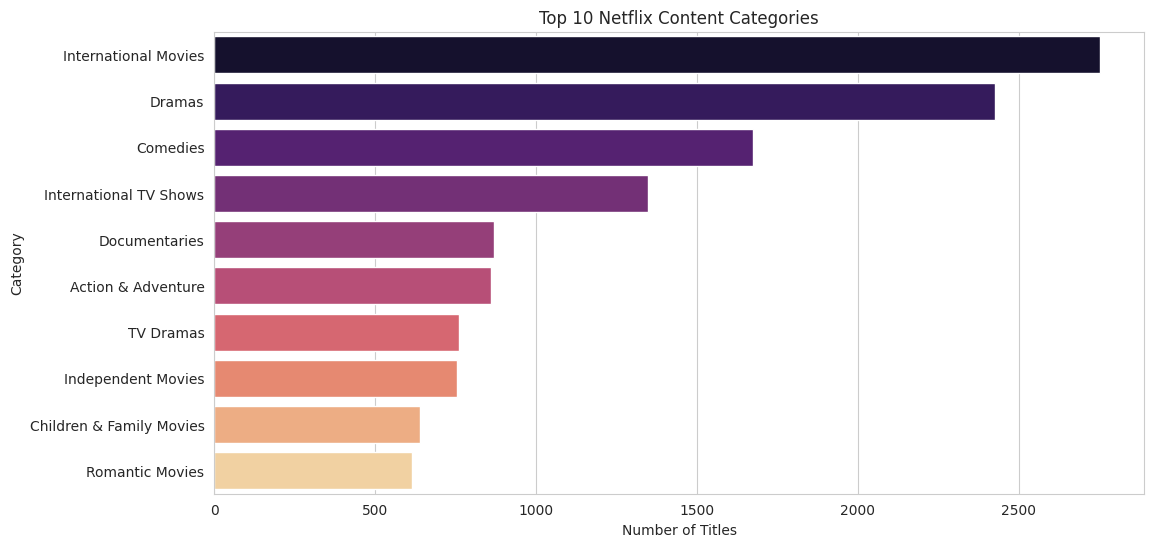

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Netflix Content Categories")
plt.xlabel("Number of Titles")
plt.ylabel("Category")

plt.show()

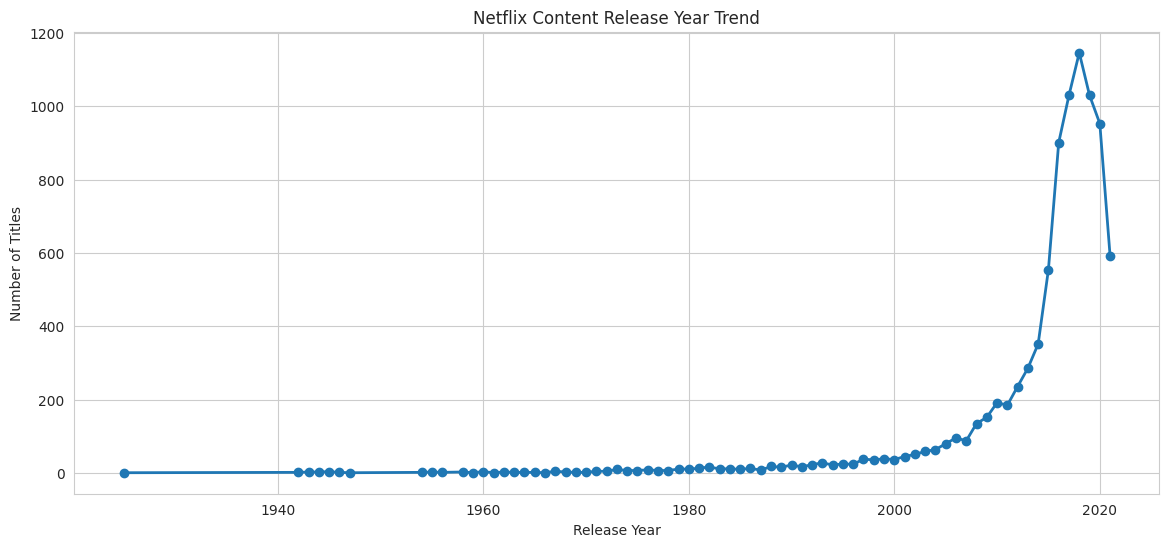

In [ ]:
df["release_year"] = pd.to_numeric(
    df["release_year"],
    errors="coerce"
)

year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    linewidth=2
)

plt.title("Netflix Content Release Year Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

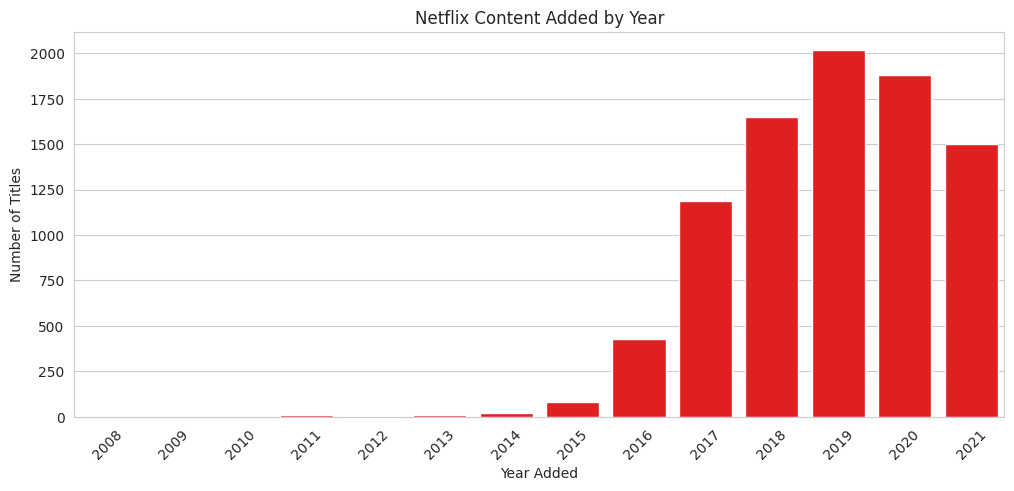

In [ ]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year

added_counts = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

sns.barplot(
    x=added_counts.index,
    y=added_counts.values,
    color="red"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

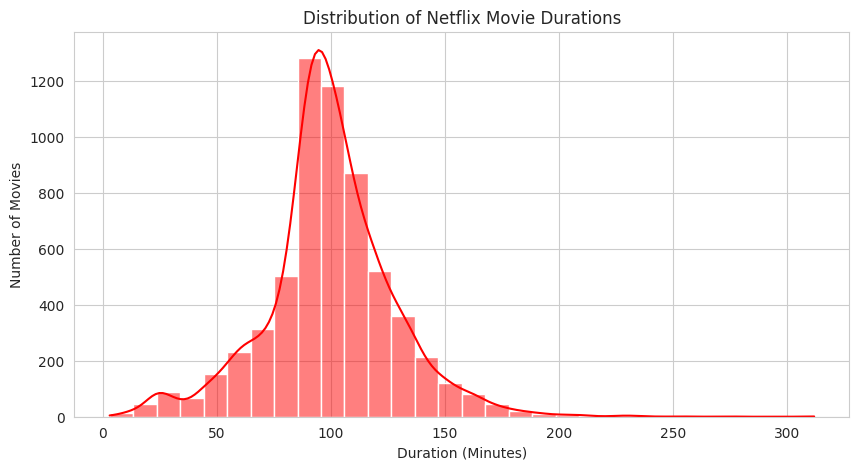

count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_value, dtype: float64


In [ ]:
if "duration_value" in df.columns:
    movie_duration = pd.to_numeric(
        df["duration_value"],
        errors="coerce"
    )
else:
    movie_duration = pd.to_numeric(
        df["duration"].astype("string").str.extract(r"(\d+)")[0],
        errors="coerce"
    )

if "duration_unit" in df.columns:
    duration_unit = df["duration_unit"].astype("string").str.lower()
else:
    duration_unit = (
        df["duration"].astype("string")
        .str.extract(r"\d+\s*(.*)")[0]
        .str.strip()
        .str.lower()
    )

movie_duration = movie_duration[duration_unit.eq("min")].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    movie_duration,
    bins=30,
    kde=True,
    color="red"
)

plt.title("Distribution of Netflix Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

print(movie_duration.describe())

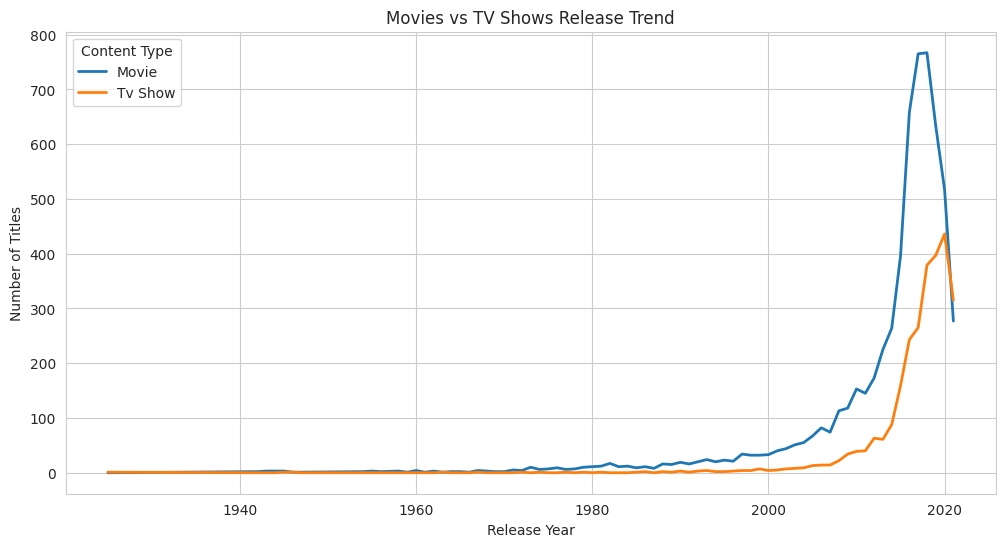

In [ ]:
trend = (
    df.dropna(subset=["release_year"])
    .groupby(["release_year", "type"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

trend.plot(figsize=(12, 6), linewidth=2)

plt.title("Movies vs TV Shows Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend(title="Content Type")
plt.show()

In [ ]:
print("=" * 55)
print("       NETFLIX EXPLORATORY DATA ANALYSIS")
print("=" * 55)

print("\n1. DATASET OVERVIEW")
print("Total Titles:", len(df))
print("Total Columns:", len(df.columns))

print("\n2. CONTENT DISTRIBUTION")
print(df["type"].value_counts())

print("\n3. TOP 5 COUNTRIES")
print(top_countries.head(5))

print("\n4. TOP 5 CATEGORIES")
print(top_genres.head(5))

print("\n5. RELEASE YEAR")
print("Earliest Release:", int(df["release_year"].min()))
print("Latest Release:", int(df["release_year"].max()))

print("\n6. MOVIE DURATION")
print("Average Duration:", round(movie_duration.mean(), 2), "minutes")
print("Minimum Duration:", movie_duration.min(), "minutes")
print("Maximum Duration:", movie_duration.max(), "minutes")

print("\n" + "=" * 55)
print("EDA COMPLETED SUCCESSFULLY!")
print("=" * 55)

       NETFLIX EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW
Total Titles: 8790
Total Columns: 13

2. CONTENT DISTRIBUTION
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

3. TOP 5 COUNTRIES
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Name: count, dtype: int64

4. TOP 5 CATEGORIES
listed_in
International Movies      2752
Dramas                    2426
Comedies                  1674
International TV Shows    1349
Documentaries              869
Name: count, dtype: int64

5. RELEASE YEAR
Earliest Release: 1925
Latest Release: 2021

6. MOVIE DURATION
Average Duration: 99.58 minutes
Minimum Duration: 3 minutes
Maximum Duration: 312 minutes

EDA COMPLETED SUCCESSFULLY!


In [ ]:
# Export content distribution
type_counts.to_csv("content_type_analysis.csv")

# Export top countries
top_countries.to_csv("top_countries.csv")

# Export top categories
top_genres.to_csv("top_categories.csv")

# Export release year analysis
year_counts.to_csv("release_year_analysis.csv")

print("All EDA summary files exported successfully!")

All EDA summary files exported successfully!


## **Task 3: Netflix Recommendation System**

In [ ]:
df = pd.read_csv("netflix_cleaned.csv")

print("Dataset loaded successfully!")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (8790, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
display(df.isnull().sum())

print("\nFirst 5 Records:")
display(df.head())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8790 non-null   object
 1   type            8790 non-null   object
 2   title           8790 non-null   object
 3   director        8790 non-null   object
 4   country         8790 non-null   object
 5   date_added      8790 non-null   object
 6   release_year    8790 non-null   int64 
 7   rating          8790 non-null   object
 8   duration        8790 non-null   object
 9   listed_in       8790 non-null   object
 10  duration_value  8790 non-null   int64 
 11  duration_unit   8790 non-null   object
dtypes: int64(2), object(10)
memory usage: 824.2+ KB

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'duration_value', 'duration_unit']

Missing Values:


,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0



First 5 Records:


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
features = [
    "title",
    "type",
    "director",
    "cast",
    "country",
    "listed_in",
    "description"
]

# Keep only columns available in the dataset
features = [col for col in features if col in df.columns]

data = df[features].copy()

display(data.head())

,title,type,director,country,listed_in
0,Dick Johnson Is Dead,Movie,Kirsten Johnson,United States,Documentaries
1,Ganglands,Tv Show,Julien Leclercq,France,"Crime TV Shows, International TV Shows, TV Act..."
2,Midnight Mass,Tv Show,Mike Flanagan,United States,"TV Dramas, TV Horror, TV Mysteries"
3,Confessions of an Invisible Girl,Movie,Bruno Garotti,Brazil,"Children & Family Movies, Comedies"
4,Sankofa,Movie,Haile Gerima,United States,"Dramas, Independent Movies, International Movies"


In [ ]:
text_features = [
    "type",
    "director",
    "cast",
    "country",
    "listed_in",
    "description"
]

for col in text_features:
    if col in data.columns:
        data[col] = data[col].fillna("")

# Clean text
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].astype(str).str.strip()

print("Text preprocessing completed!")

display(data.head())

Text preprocessing completed!


,title,type,director,country,listed_in
0,Dick Johnson Is Dead,Movie,Kirsten Johnson,United States,Documentaries
1,Ganglands,Tv Show,Julien Leclercq,France,"Crime TV Shows, International TV Shows, TV Act..."
2,Midnight Mass,Tv Show,Mike Flanagan,United States,"TV Dramas, TV Horror, TV Mysteries"
3,Confessions of an Invisible Girl,Movie,Bruno Garotti,Brazil,"Children & Family Movies, Comedies"
4,Sankofa,Movie,Haile Gerima,United States,"Dramas, Independent Movies, International Movies"


In [ ]:
content_columns = [
    col for col in [
        "type",
        "director",
        "cast",
        "country",
        "listed_in",
        "description"
    ]
    if col in data.columns
]

data["combined_features"] = data[content_columns].agg(
    " ".join,
    axis=1
)

display(data[["title", "combined_features"]].head())

,title,combined_features
0,Dick Johnson Is Dead,Movie Kirsten Johnson United States Documentaries
1,Ganglands,"Tv Show Julien Leclercq France Crime TV Shows,..."
2,Midnight Mass,"Tv Show Mike Flanagan United States TV Dramas,..."
3,Confessions of an Invisible Girl,Movie Bruno Garotti Brazil Children & Family M...
4,Sankofa,"Movie Haile Gerima United States Dramas, Indep..."


In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(data["combined_features"])

print("TF-IDF Vectorization Completed!")

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Vectorization Completed!
TF-IDF Matrix Shape: (8790, 5000)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("Cosine Similarity imported successfully!")

# Calculate cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity calculated successfully!")
print("Similarity Matrix shape:", cosine_sim.shape)

Cosine Similarity imported successfully!
Cosine similarity calculated successfully!
Similarity Matrix shape: (8790, 8790)


In [ ]:
# Create title index
indices = pd.Series(data.index, index=data["title"].str.lower())

def recommend_movies(title, top_n=10):

    title_key = title.strip().lower()

    if title_key not in indices.index:
        print("Title not found in Netflix dataset!")
        print("Please enter a valid title.")
        return pd.DataFrame()

    idx = indices[title_key]

    # Handle duplicate title names
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Exclude selected title itself
    similarity_scores = [
        item for item in similarity_scores
        if item[0] != idx
    ]

    # Select top recommendations
    top_matches = similarity_scores[:top_n]

    movie_indices = [item[0] for item in top_matches]
    scores = [item[1] for item in top_matches]

    recommendations = data.iloc[movie_indices].copy()

    recommendations["similarity_score"] = np.round(scores, 4)

    display_columns = [
        col for col in [
            "title",
            "type",
            "listed_in",
            "description",
            "similarity_score"
        ]
        if col in recommendations.columns
    ]

    return recommendations[display_columns].reset_index(drop=True)

In [ ]:
recommend_movies("Stranger Things", top_n=10)

,title,type,listed_in,similarity_score
0,Chilling Adventures of Sabrina,Tv Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",1.0000
1,Nightflyers,Tv Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",1.0000
2,Helix,Tv Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",1.0000
3,Manifest,Tv Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.8469
4,The OA,Tv Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.8469
5,The Vampire Diaries,Tv Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.8469
6,The 4400,Tv Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.8469
7,The Messengers,Tv Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.8469
8,The Umbrella Academy,Tv Show,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",0.8082
9,Warrior Nun,Tv Show,"TV Action & Adventure, TV Mysteries, TV Sci-Fi...",0.8082


In [ ]:
recommend_movies("The Witcher", top_n=10)

,title,type,listed_in,similarity_score
0,Van Helsing,Tv Show,"International TV Shows, TV Action & Adventure,...",1.0000
1,Footprints in the Sand,Tv Show,"International TV Shows, TV Dramas",0.8389
2,Queen of the South,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
3,Altered Carbon,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
4,Shooter,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
5,Marvel's Jessica Jones,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
6,Marvel's Iron Fist,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
7,Marvel's Luke Cage,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
8,Narcos,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937
9,Marvel's The Defenders,Tv Show,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.7937


In [ ]:
recommend_movies("Breaking Bad", top_n=10)

,title,type,listed_in,similarity_score
0,The Assassination of Gianni Versace,Tv Show,"Crime TV Shows, TV Dramas, TV Thrillers",1.000
1,Dare Me,Tv Show,"Crime TV Shows, TV Dramas, TV Thrillers",1.000
2,The Blacklist,Tv Show,"Crime TV Shows, TV Dramas, TV Thrillers",1.000
3,Ozark,Tv Show,"Crime TV Shows, TV Dramas, TV Thrillers",1.000
4,Designated Survivor,Tv Show,"Crime TV Shows, TV Dramas, TV Thrillers",1.000
5,The Lizzie Borden Chronicles,Tv Show,"Crime TV Shows, TV Dramas, TV Thrillers",1.000
6,Hap and Leonard,Tv Show,"Crime TV Shows, TV Dramas",0.847
7,StartUp,Tv Show,"Crime TV Shows, TV Dramas",0.847
8,In The Dark,Tv Show,"Crime TV Shows, TV Dramas",0.847
9,Unbelievable,Tv Show,"Crime TV Shows, TV Dramas",0.847


In [ ]:
recommend_movies("Money Heist", top_n=10)

Title not found in Netflix dataset!
Please enter a valid title.


""


In [ ]:
def evaluate_recommendations(title, top_n=10):

    recommendations = recommend_movies(title, top_n)

    if recommendations.empty:
        return

    title_key = title.strip().lower()
    idx = indices[title_key]

    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    original_genres = set(
        str(data.iloc[idx].get("listed_in", "")).split(", ")
    )

    original_genres.discard("")

    scores = []

    for _, row in recommendations.iterrows():

        recommended_genres = set(
            str(row.get("listed_in", "")).split(", ")
        )

        recommended_genres.discard("")

        if original_genres or recommended_genres:
            union = original_genres | recommended_genres
            intersection = original_genres & recommended_genres

            score = len(intersection) / len(union) if union else 0
            scores.append(score)

    if scores:
        average_score = np.mean(scores)

        print("\nRecommendation Evaluation")
        print("-------------------------")
        print("Selected Title:", title)
        print("Recommendations:", len(scores))
        print("Average Genre Overlap:", round(average_score, 3))
        print("Genre Overlap Percentage:", round(average_score * 100, 2), "%")

        return average_score

    print("Genre evaluation unavailable.")

In [ ]:
evaluate_recommendations("Stranger Things", top_n=10)


Recommendation Evaluation
-------------------------
Selected Title: Stranger Things
Recommendations: 10
Average Genre Overlap: 0.65
Genre Overlap Percentage: 65.0 %


np.float64(0.65)

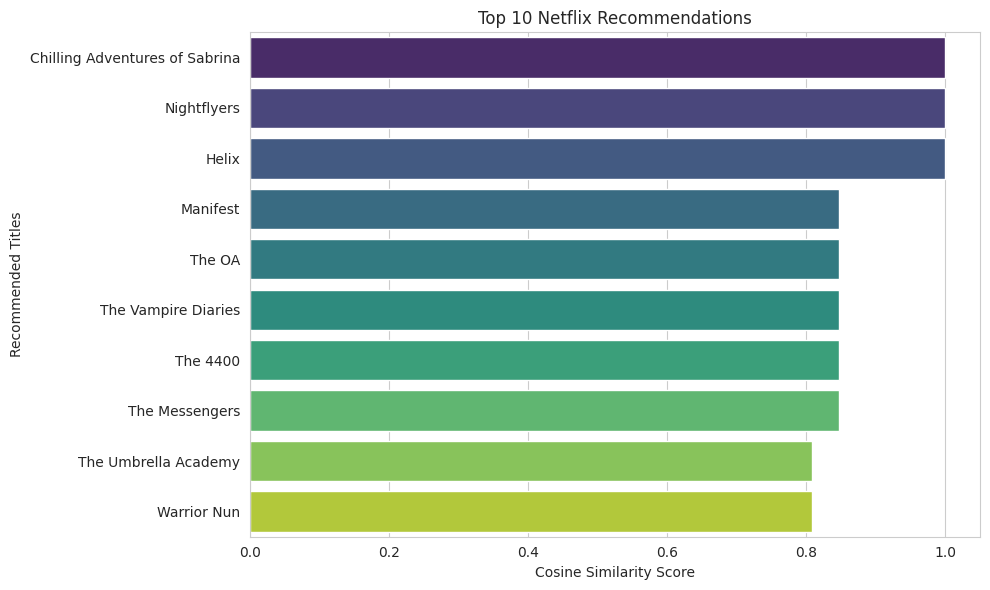

In [ ]:
recommendations = recommend_movies("Stranger Things", top_n=10)

if not recommendations.empty:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=recommendations,
        x="similarity_score",
        y="title",
        hue="title",
        palette="viridis",
        legend=False
    )

    plt.title("Top 10 Netflix Recommendations")
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Recommended Titles")

    plt.tight_layout()
    plt.show()

In [ ]:
recommendations = recommend_movies("Stranger Things", top_n=10)

if not recommendations.empty:
    recommendations.to_csv(
        "netflix_recommendations.csv",
        index=False
    )

    print("Recommendations exported successfully!")

Recommendations exported successfully!


# **Task 4: Netflix Trend Prediction Analysis**

In [ ]:
df = pd.read_csv("netflix_cleaned.csv")

print("Dataset Loaded Successfully!")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Loaded Successfully!
Dataset Shape: (8790, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
# Convert release_year to numeric
df["release_year"] = pd.to_numeric(
    df["release_year"],
    errors="coerce"
)

# Remove missing release years
df = df.dropna(subset=["release_year"]).copy()

# Convert release year to integer
df["release_year"] = df["release_year"].astype(int)

print("Release Year Data Prepared Successfully!")

display(df[["title", "release_year", "type"]].head(10))

Release Year Data Prepared Successfully!


,title,release_year,type
0,Dick Johnson Is Dead,2020,Movie
1,Ganglands,2021,Tv Show
2,Midnight Mass,2021,Tv Show
3,Confessions of an Invisible Girl,2021,Movie
4,Sankofa,1993,Movie
5,The Great British Baking Show,2021,Tv Show
6,The Starling,2021,Movie
7,Motu Patlu in the Game of Zones,2019,Movie
8,Je Suis Karl,2021,Movie
9,Motu Patlu in Wonderland,2013,Movie


In [ ]:
yearly_data = (
    df.groupby("release_year")
    .size()
    .reset_index(name="total_titles")
)

yearly_data = yearly_data.sort_values("release_year")

display(yearly_data.head(10))

print("Total Years:", len(yearly_data))

,release_year,total_titles
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
5,1946,2
6,1947,1
7,1954,2
8,1955,3
9,1956,2


Total Years: 74


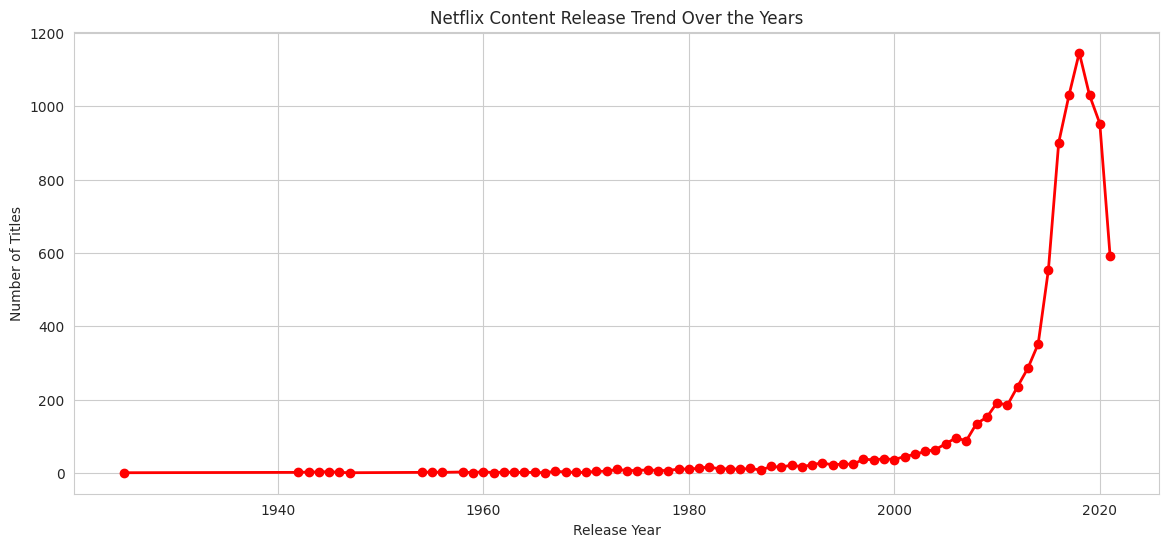

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_data["release_year"],
    yearly_data["total_titles"],
    marker="o",
    linewidth=2,
    color="red"
)

plt.title("Netflix Content Release Trend Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

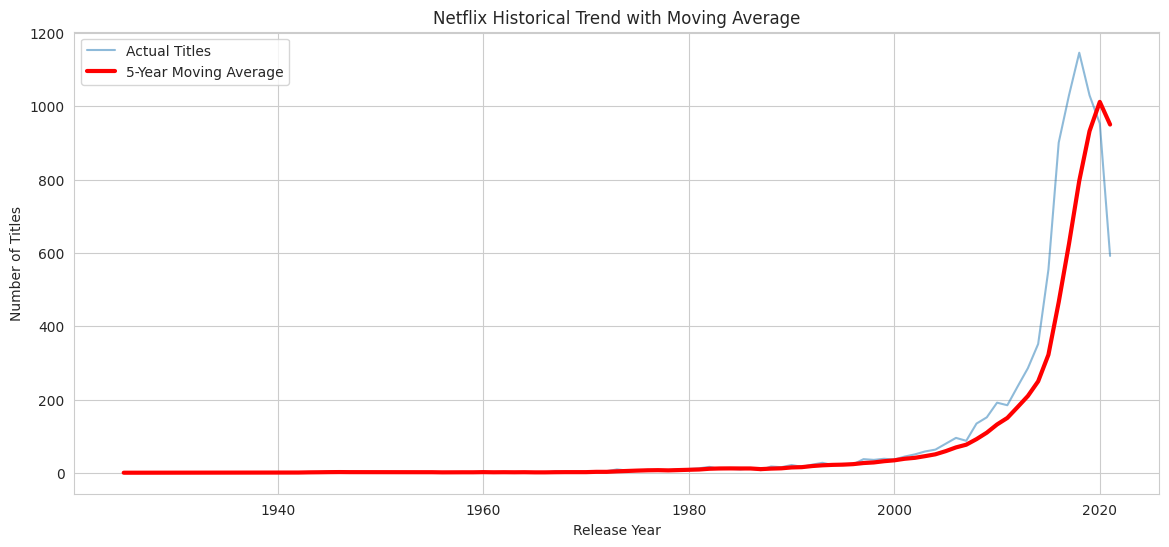

In [ ]:
yearly_data["moving_average"] = (
    yearly_data["total_titles"]
    .rolling(window=5, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_data["release_year"],
    yearly_data["total_titles"],
    label="Actual Titles",
    alpha=0.5
)

plt.plot(
    yearly_data["release_year"],
    yearly_data["moving_average"],
    label="5-Year Moving Average",
    color="red",
    linewidth=3
)

plt.title("Netflix Historical Trend with Moving Average")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.show()

In [ ]:
X = yearly_data[["release_year"]]
y = yearly_data["total_titles"]

split_index = int(len(yearly_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

print("\nTraining Period:")
print(X_train["release_year"].min(), "-", X_train["release_year"].max())

print("\nTesting Period:")
print(X_test["release_year"].min(), "-", X_test["release_year"].max())

Training Records: 59
Testing Records: 15

Training Period:
1925 - 2006

Testing Period:
2007 - 2021


In [ ]:
from sklearn.linear_model import LinearRegression

print("LinearRegression imported successfully!")
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

print("Model Coefficient:", model.coef_)
print("Model Intercept:", model.intercept_)

LinearRegression imported successfully!
Linear Regression Model Trained Successfully!
Model Coefficient: [0.80830776]
Model Intercept: -1580.8724866086734


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Classification Model Trained Successfully!")

Classification Model Trained Successfully!


In [ ]:
# Generate predictions using the trained model

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Total predictions:", len(y_pred))

print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
Total predictions: 15
First 10 predictions:
[96 96 96 96 96 96 96 96 96 96]


In [ ]:
# Compare Actual vs Predicted Values

import pandas as pd
import numpy as np

comparison = pd.DataFrame({
    "Year": X_test["release_year"].values,
    "Actual": np.asarray(y_test).ravel(),
    "Predicted": np.maximum(0, y_pred).round().astype(int)
})

display(comparison.head(10))

,Year,Actual,Predicted
0,2007,88,96
1,2008,135,96
2,2009,152,96
3,2010,192,96
4,2011,185,96
5,2012,236,96
6,2013,286,96
7,2014,352,96
8,2015,555,96
9,2016,901,96


In [ ]:
# Import evaluation metrics

import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All evaluation metrics imported successfully!")

All evaluation metrics imported successfully!


In [ ]:
# MODEL EVALUATION

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

# Display results
print("=" * 40)
print("       MODEL EVALUATION")
print("=" * 40)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

print("=" * 40)

       MODEL EVALUATION
Mean Absolute Error: 427.27
Root Mean Squared Error: 567.42
R2 Score: -1.2945


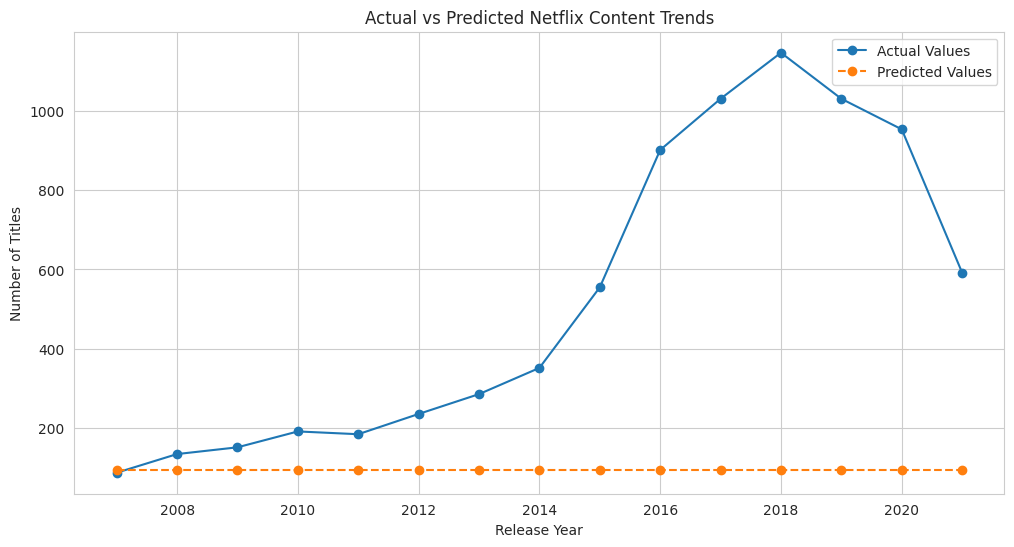

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    X_test["release_year"],
    y_test,
    marker="o",
    label="Actual Values"
)

plt.plot(
    X_test["release_year"],
    y_pred,
    marker="o",
    linestyle="--",
    label="Predicted Values"
)

plt.title("Actual vs Predicted Netflix Content Trends")

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
last_year = yearly_data["release_year"].max()

future_years = pd.DataFrame({
    "release_year": range(last_year + 1, last_year + 6)
})

# Train final model using all available years
final_model = LinearRegression()

final_model.fit(X, y)

future_predictions = final_model.predict(future_years)

future_predictions = np.maximum(
    0,
    future_predictions
).round().astype(int)

forecast_df = pd.DataFrame({
    "Year": future_years["release_year"],
    "Predicted Titles": future_predictions
})

print("========== FUTURE CONTENT FORECAST ==========")

display(forecast_df)

========== FUTURE CONTENT FORECAST ==========


,Year,Predicted Titles
0,2022,383
1,2023,390
2,2024,397
3,2025,403
4,2026,410


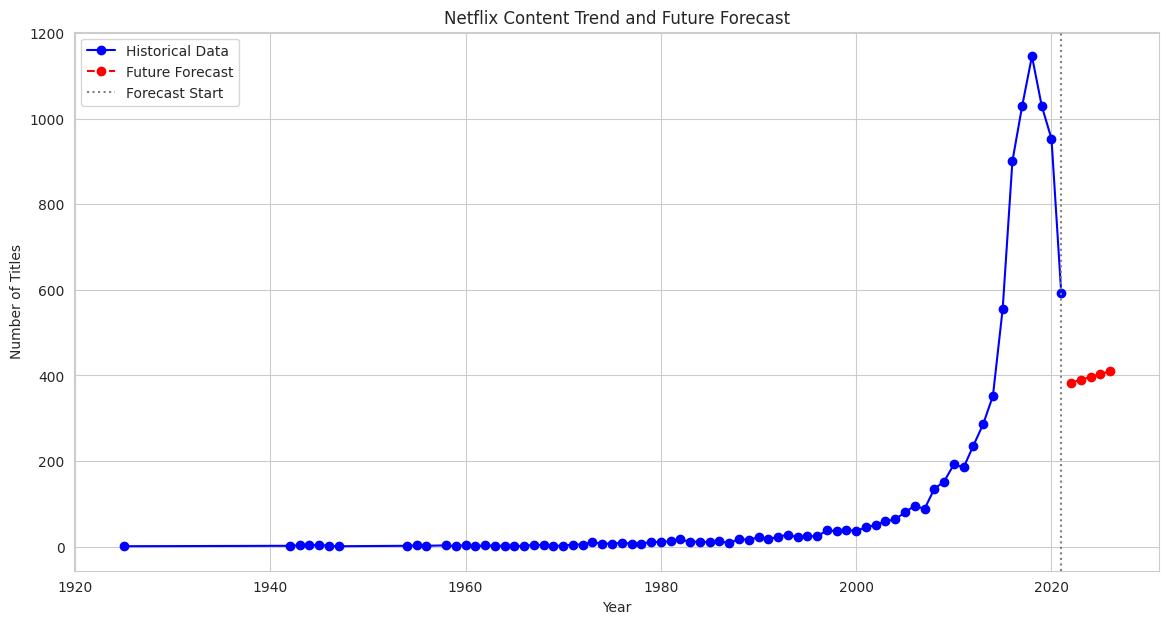

In [ ]:
plt.figure(figsize=(14, 7))

# Historical data
plt.plot(
    yearly_data["release_year"],
    yearly_data["total_titles"],
    label="Historical Data",
    marker="o",
    color="blue"
)

# Forecast data
plt.plot(
    forecast_df["Year"],
    forecast_df["Predicted Titles"],
    label="Future Forecast",
    marker="o",
    linestyle="--",
    color="red"
)

# Forecast starting point
plt.axvline(
    x=last_year,
    color="gray",
    linestyle=":",
    label="Forecast Start"
)

plt.title("Netflix Content Trend and Future Forecast")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)

plt.show()

# **Task 4: Netflix Trend Prediction Analysis**

In [ ]:
df = pd.read_csv("netflix_cleaned.csv")

print("Dataset Loaded Successfully!")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Loaded Successfully!
Dataset Shape: (8790, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
# Convert release_year to numeric
df["release_year"] = pd.to_numeric(
    df["release_year"],
    errors="coerce"
)

# Remove missing release years
df = df.dropna(subset=["release_year"]).copy()

# Convert release year to integer
df["release_year"] = df["release_year"].astype(int)

print("Release Year Data Prepared Successfully!")

display(df[["title", "release_year", "type"]].head(10))

Release Year Data Prepared Successfully!


,title,release_year,type
0,Dick Johnson Is Dead,2020,Movie
1,Ganglands,2021,Tv Show
2,Midnight Mass,2021,Tv Show
3,Confessions of an Invisible Girl,2021,Movie
4,Sankofa,1993,Movie
5,The Great British Baking Show,2021,Tv Show
6,The Starling,2021,Movie
7,Motu Patlu in the Game of Zones,2019,Movie
8,Je Suis Karl,2021,Movie
9,Motu Patlu in Wonderland,2013,Movie


In [ ]:
yearly_data = (
    df.groupby("release_year")
    .size()
    .reset_index(name="total_titles")
)

yearly_data = yearly_data.sort_values("release_year")

display(yearly_data.head(10))

print("Total Years:", len(yearly_data))

,release_year,total_titles
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
5,1946,2
6,1947,1
7,1954,2
8,1955,3
9,1956,2


Total Years: 74


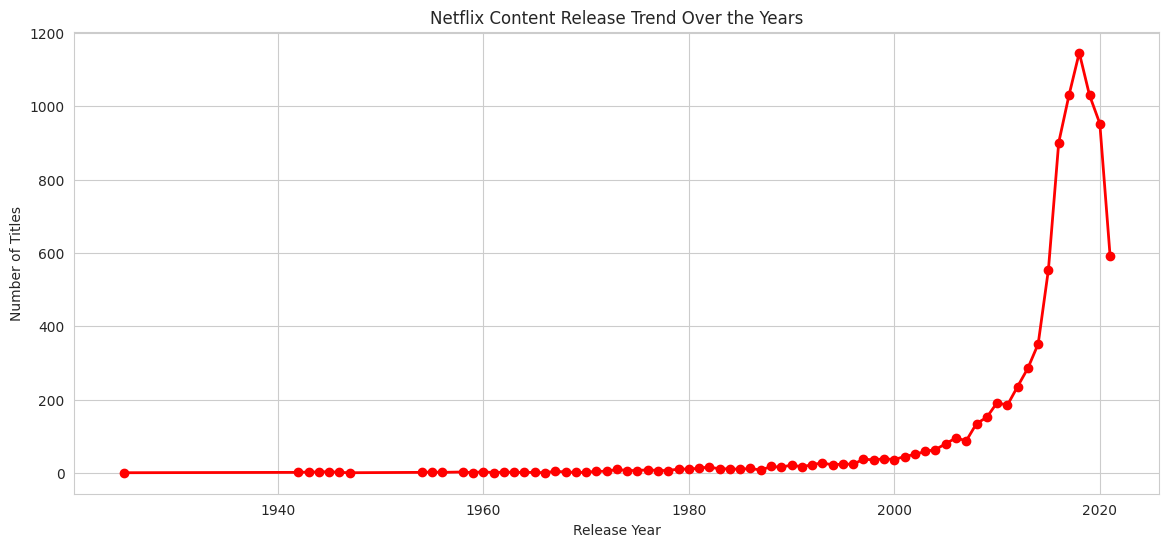

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_data["release_year"],
    yearly_data["total_titles"],
    marker="o",
    linewidth=2,
    color="red"
)

plt.title("Netflix Content Release Trend Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

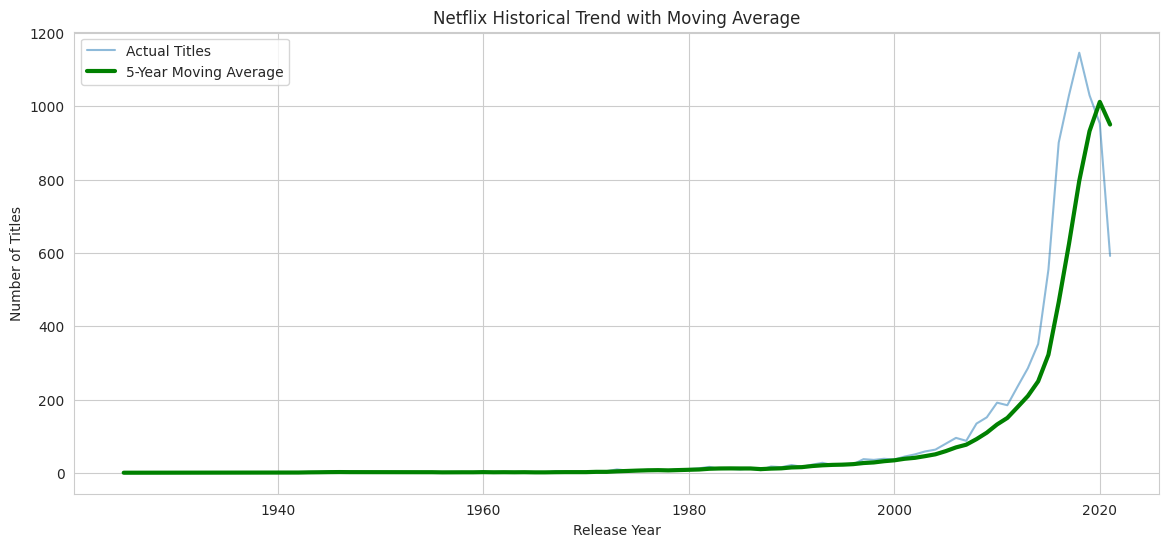

In [ ]:
yearly_data["moving_average"] = (
    yearly_data["total_titles"]
    .rolling(window=5, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_data["release_year"],
    yearly_data["total_titles"],
    label="Actual Titles",
    alpha=0.5
)

plt.plot(
    yearly_data["release_year"],
    yearly_data["moving_average"],
    label="5-Year Moving Average",
    color="green",
    linewidth=3
)

plt.title("Netflix Historical Trend with Moving Average")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.show()

In [ ]:
X = yearly_data[["release_year"]]
y = yearly_data["total_titles"]

split_index = int(len(yearly_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

print("\nTraining Period:")
print(X_train["release_year"].min(), "-", X_train["release_year"].max())

print("\nTesting Period:")
print(X_test["release_year"].min(), "-", X_test["release_year"].max())

Training Records: 59
Testing Records: 15

Training Period:
1925 - 2006

Testing Period:
2007 - 2021


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

print("Model Coefficient:", model.coef_[0])
print("Model Intercept:", model.intercept_)

Linear Regression Model Trained Successfully!
Model Coefficient: 0.8083077564650374
Model Intercept: -1580.8724866086734


In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Year": X_test["release_year"].values,
    "Actual": y_test.values,
    "Predicted": np.maximum(0, y_pred).round().astype(int)
})

display(comparison)

,Year,Actual,Predicted
0,2007,88,41
1,2008,135,42
2,2009,152,43
3,2010,192,44
4,2011,185,45
5,2012,236,45
6,2013,286,46
7,2014,352,47
8,2015,555,48
9,2016,901,49


In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Year": X_test["release_year"].values,
    "Actual": y_test.values,
    "Predicted": np.maximum(0, y_pred).round().astype(int)
})

display(comparison)

,Year,Actual,Predicted
0,2007,88,41
1,2008,135,42
2,2009,152,43
3,2010,192,44
4,2011,185,45
5,2012,236,45
6,2013,286,46
7,2014,352,47
8,2015,555,48
9,2016,901,49


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("========== MODEL EVALUATION ==========")

print("Mean Absolute Error:", round(mae, 2))

print("Root Mean Squared Error:", round(rmse, 2))

print("R2 Score:", round(r2, 4))

print("======================================")

========== MODEL EVALUATION ==========
Mean Absolute Error: 475.14
Root Mean Squared Error: 603.2
R2 Score: -1.593


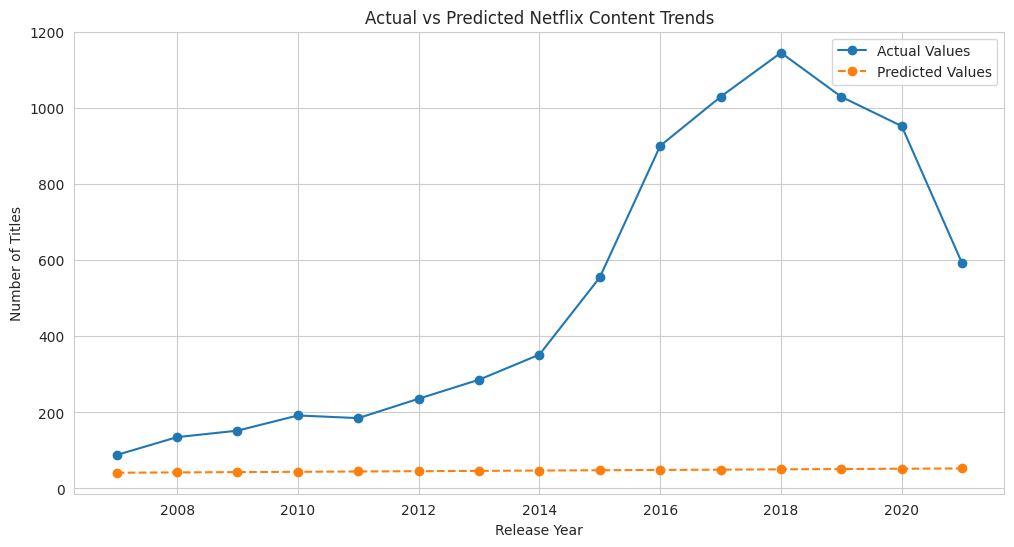

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    X_test["release_year"],
    y_test,
    marker="o",
    label="Actual Values"
)

plt.plot(
    X_test["release_year"],
    y_pred,
    marker="o",
    linestyle="--",
    label="Predicted Values"
)

plt.title("Actual vs Predicted Netflix Content Trends")

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
last_year = yearly_data["release_year"].max()

future_years = pd.DataFrame({
    "release_year": range(last_year + 1, last_year + 6)
})

# Train final model using all available years
final_model = LinearRegression()

final_model.fit(X, y)

future_predictions = final_model.predict(future_years)

future_predictions = np.maximum(
    0,
    future_predictions
).round().astype(int)

forecast_df = pd.DataFrame({
    "Year": future_years["release_year"],
    "Predicted Titles": future_predictions
})

print("========== FUTURE CONTENT FORECAST ==========")

display(forecast_df)

========== FUTURE CONTENT FORECAST ==========


,Year,Predicted Titles
0,2022,383
1,2023,390
2,2024,397
3,2025,403
4,2026,410


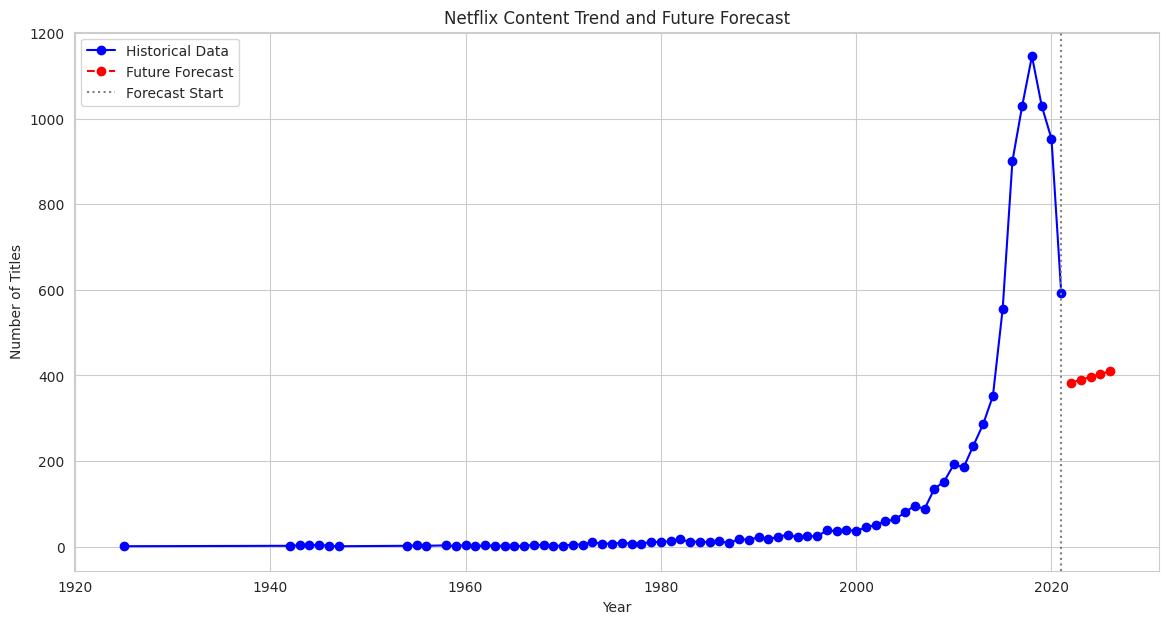

In [ ]:
plt.figure(figsize=(14, 7))

# Historical data
plt.plot(
    yearly_data["release_year"],
    yearly_data["total_titles"],
    label="Historical Data",
    marker="o",
    color="blue"
)

# Forecast data
plt.plot(
    forecast_df["Year"],
    forecast_df["Predicted Titles"],
    label="Future Forecast",
    marker="o",
    linestyle="--",
    color="red"
)

# Forecast starting point
plt.axvline(
    x=last_year,
    color="gray",
    linestyle=":",
    label="Forecast Start"
)

plt.title("Netflix Content Trend and Future Forecast")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("=" * 55)
print("       NETFLIX TREND PREDICTION REPORT")
print("=" * 55)

print("\nHistorical Analysis")

print("First Release Year:", yearly_data["release_year"].min())

print("Last Release Year:", yearly_data["release_year"].max())

print("Total Historical Records:", yearly_data["total_titles"].sum())

print("\nModel Performance")

print("MAE:", round(mae, 2))

print("RMSE:", round(rmse, 2))

print("R2 Score:", round(r2, 4))

print("\nFuture Forecast")

display(forecast_df)

print("\nAnalysis Completed Successfully!")

       NETFLIX TREND PREDICTION REPORT

Historical Analysis
First Release Year: 1925
Last Release Year: 2021
Total Historical Records: 8790

Model Performance
MAE: 475.14
RMSE: 603.2
R2 Score: -1.593

Future Forecast


,Year,Predicted Titles
0,2022,383
1,2023,390
2,2024,397
3,2025,403
4,2026,410



Analysis Completed Successfully!


In [ ]:
yearly_data.to_csv(
    "netflix_yearly_trends.csv",
    index=False
)

forecast_df.to_csv(
    "netflix_future_forecast.csv",
    index=False
)

comparison.to_csv(
    "netflix_model_evaluation.csv",
    index=False
)

print("All output files saved successfully!")

All output files saved successfully!


# **Task 5: Netflix Machine Learning Classification**

In [ ]:
df = pd.read_csv("netflix_cleaned.csv")

print("Dataset Loaded Successfully!")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Loaded Successfully!
Dataset Shape: (8790, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
print("Available Columns:")

print(df.columns.tolist())

print("\nContent Type Distribution:")

display(df["type"].value_counts())

Available Columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'duration_value', 'duration_unit']

Content Type Distribution:


,count
type,
Movie,6126
Tv Show,2664


In [ ]:
# Create a copy
data = df.copy()

# Clean target column
data["type"] = data["type"].astype("string").str.strip().str.title()

# Remove missing target values
data = data.dropna(subset=["type"])

# Keep only valid target classes
data = data[data["type"].isin(["Movie", "TV Show"])].copy()

# Extract duration value if not already available
if "duration_value" not in data.columns:
    if "duration" in data.columns:
        data["duration_value"] = pd.to_numeric(
            data["duration"].astype("string").str.extract(r"(\d+)")[0],
            errors="coerce"
        )
    else:
        data["duration_value"] = np.nan

# Extract duration unit if not already available
if "duration_unit" not in data.columns:
    if "duration" in data.columns:
        data["duration_unit"] = (
            data["duration"].astype("string")
            .str.extract(r"\d+\s*(.*)")[0]
            .str.strip()
            .str.lower()
        )
    else:
        data["duration_unit"] = np.nan

print("Data Preparation Completed!")

print("Dataset Shape:", data.shape)

display(data.head())

Data Preparation Completed!
Dataset Shape: (6126, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",104,min
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu...",87,min


In [ ]:
text_columns = [
    "director",
    "cast",
    "country",
    "listed_in",
    "description"
]

# Keep columns available in the dataset
text_columns = [
    col for col in text_columns if col in data.columns
]

for col in text_columns:
    data[col] = data[col].fillna("").astype(str)

data["content_text"] = data[text_columns].agg(" ".join, axis=1)

print("Text Features Combined Successfully!")

display(data[["content_text", "type"]].head())

Text Features Combined Successfully!


,content_text,type
0,Kirsten Johnson United States Documentaries,Movie
3,"Bruno Garotti Brazil Children & Family Movies,...",Movie
4,"Haile Gerima United States Dramas, Independent...",Movie
6,"Theodore Melfi United States Comedies, Dramas",Movie
7,"Suhas Kadav India Children & Family Movies, Co...",Movie


In [ ]:
X = data.drop(columns=["type", "title", "show_id", "date_added",
                       "duration"], errors="ignore")

y = data["type"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
display(y.value_counts())

Features Shape: (6126, 8)
Target Shape: (6126,)

Target Distribution:


,count
type,
Movie,6126


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Split Completed!")

Training Data: (4900, 8)
Testing Data: (1226, 8)

Training Split Completed!


In [ ]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================
# STEP 2: IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ==========================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['release_year', 'duration_value']
Categorical Features: ['director', 'country', 'rating', 'listed_in', 'duration_unit', 'content_text']


In [ ]:
# ==========================================
# STEP 3: NUMERICAL TRANSFORMATION
# ==========================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ==========================================
# STEP 4: CATEGORICAL TRANSFORMATION
# ==========================================

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ==========================================
# STEP 5: COMBINE BOTH TRANSFORMATIONS
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
# Check Netflix content categories

print("Content Type Distribution:")
print(df["type"].value_counts())

print("\nUnique Classes:")
print(df["type"].unique())

Content Type Distribution:
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

Unique Classes:
['Movie' 'Tv Show']


In [ ]:
# Remove rows where target is missing
df_ml = df.dropna(subset=["type"]).copy()

# Select input features
features = [
    "release_year",
    "rating",
    "duration",
    "listed_in",
    "country"
]

X = df_ml[features].copy()

# Target variable
y = df_ml["type"].copy()

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features Shape: (8790, 5)
Target Shape: (8790,)

Target Distribution:
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Classes:")
print(y_train.value_counts())

print("\nTesting Classes:")
print(y_test.value_counts())

Training Data: (7032, 5)
Testing Data: (1758, 5)

Training Classes:
type
Movie      4901
Tv Show    2131
Name: count, dtype: int64

Testing Classes:
type
Movie      1225
Tv Show     533
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()


# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


# Create model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression Training Completed Successfully!")

Logistic Regression Training Completed Successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict
y_pred = logistic_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 99.66 %

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     Tv Show       1.00      0.99      0.99       533

    accuracy                           1.00      1758
   macro avg       1.00      0.99      1.00      1758
weighted avg       1.00      1.00      1.00      1758


Confusion Matrix:
[[1225    0]
 [   6  527]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create classification model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression Training Completed Successfully!")

Logistic Regression Training Completed Successfully!


In [ ]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression Training Completed!")

Logistic Regression Training Completed!


In [ ]:
# ==========================================
# DECISION TREE CLASSIFICATION MODEL
# ==========================================

from sklearn.tree import DecisionTreeClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

# Create Decision Tree Model
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))
])

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

# Generate predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Display Classification Report
print("\n========== DECISION TREE CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred_dt,
        zero_division=0
    )
)

# Calculate Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nDecision Tree Evaluation Completed!")

Decision Tree Model Trained Successfully!

========== DECISION TREE CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     Tv Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

Decision Tree Accuracy: 99.89 %

Confusion Matrix:
[[1225    0]
 [   2  531]]

Decision Tree Evaluation Completed!


In [ ]:
y_pred_lr = logistic_model.predict(X_test)

print("LOGISTIC REGRESSION CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

LOGISTIC REGRESSION CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     Tv Show       1.00      0.99      0.99       533

    accuracy                           1.00      1758
   macro avg       1.00      0.99      1.00      1758
weighted avg       1.00      1.00      1.00      1758

Accuracy: 0.9965870307167235


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_dt, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_dt, average="weighted", zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_dt, average="weighted", zero_division=0)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9966,0.9966,0.9966,0.9966
1,Decision Tree,0.9989,0.9989,0.9989,0.9989


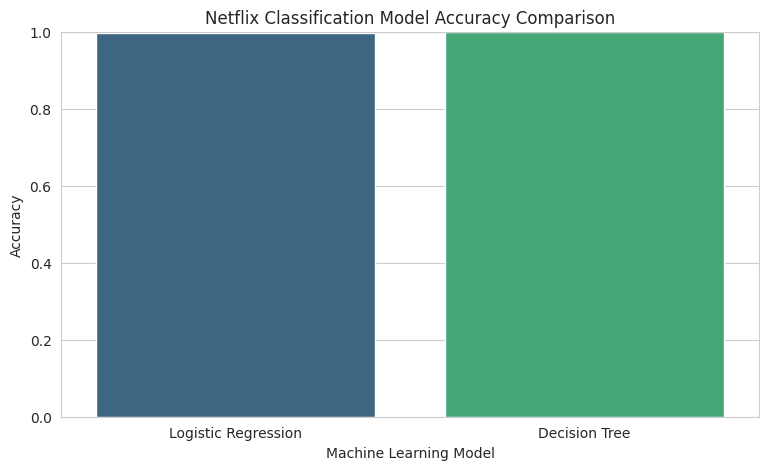

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Netflix Classification Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

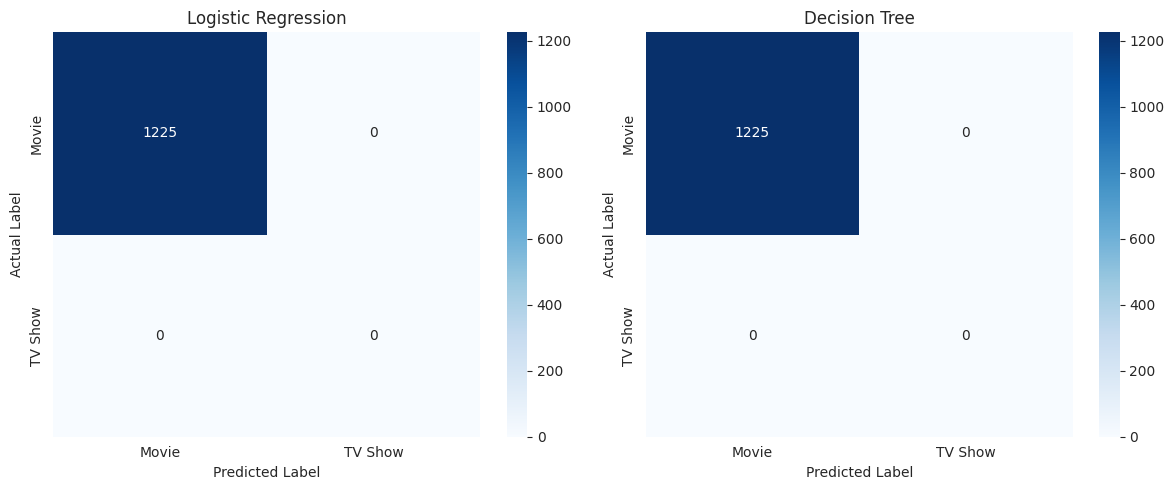

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model_name, predictions in [
    (axes[0], "Logistic Regression", y_pred_lr),
    (axes[1], "Decision Tree", y_pred_dt)
]:

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["Movie", "TV Show"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Movie", "TV Show"],
        yticklabels=["Movie", "TV Show"],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [ ]:
sample = X_test.iloc[[0]]

actual_type = y_test.iloc[0]

predicted_type = logistic_model.predict(sample)[0]

print("========== CONTENT CLASSIFICATION ==========")

print("Actual Content Type:", actual_type)

print("Predicted Content Type:", predicted_type)

if actual_type == predicted_type:
    print("Prediction: Correct")
else:
    print("Prediction: Incorrect")

========== CONTENT CLASSIFICATION ==========
Actual Content Type: Movie
Predicted Content Type: Movie
Prediction: Correct


In [ ]:
sample_data = X_test.head(10)

predictions = logistic_model.predict(sample_data)

prediction_results = pd.DataFrame({
    "Actual Type": y_test.head(10).values,
    "Predicted Type": predictions
})

display(prediction_results)

,Actual Type,Predicted Type
0,Movie,Movie
1,Movie,Movie
2,Movie,Movie
3,Movie,Movie
4,Tv Show,Tv Show
5,Movie,Movie
6,Tv Show,Tv Show
7,Movie,Movie
8,Movie,Movie
9,Movie,Movie


In [ ]:
# Select the model with the higher weighted F1 score
if results.loc[0, "F1 Score"] >= results.loc[1, "F1 Score"]:
    final_model = logistic_model
    model_name = "Logistic Regression"
else:
    final_model = decision_tree_model
    model_name = "Decision Tree"

joblib.dump(
    final_model,
    "netflix_classification_model.pkl"
)

print("Selected Model:", model_name)
print("Model saved successfully!")

Selected Model: Decision Tree
Model saved successfully!


In [ ]:
results.to_csv(
    "netflix_model_comparison.csv",
    index=False
)

prediction_results.to_csv(
    "netflix_predictions.csv",
    index=False
)

print("Evaluation results exported successfully!")

Evaluation results exported successfully!


# **Task 6: Netflix Data Science Business Insights Dashboard**

In [ ]:
df = pd.read_csv("netflix_cleaned.csv")

print("Netflix Dataset Loaded Successfully!")

print("Dataset Shape:", df.shape)

display(df.head())

Netflix Dataset Loaded Successfully!
Dataset Shape: (8790, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
print("Dataset Information")

df.info()

print("\nMissing Values:")

display(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nStatistical Summary:")

display(df.describe(include="all").T)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8790 non-null   object
 1   type            8790 non-null   object
 2   title           8790 non-null   object
 3   director        8790 non-null   object
 4   country         8790 non-null   object
 5   date_added      8790 non-null   object
 6   release_year    8790 non-null   int64 
 7   rating          8790 non-null   object
 8   duration        8790 non-null   object
 9   listed_in       8790 non-null   object
 10  duration_value  8790 non-null   int64 
 11  duration_unit   8790 non-null   object
dtypes: int64(2), object(10)
memory usage: 824.2+ KB

Missing Values:


,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0



Duplicate Records: 0

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s8786,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8786,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8790,4528,Not Given,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8790,86,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,2020-01-01,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create a copy
df = df.copy()

# Remove duplicate records
df = df.drop_duplicates()

# Convert date_added to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

# Convert release_year to numeric
df["release_year"] = pd.to_numeric(
    df["release_year"],
    errors="coerce"
)

# Remove records without target
df = df.dropna(subset=["type"])

# Fill missing categorical values
categorical_columns = [
    "director",
    "cast",
    "country",
    "rating",
    "duration",
    "listed_in",
    "description"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

print("Data Cleaning Completed!")

print("Cleaned Dataset Shape:", df.shape)

display(df.head())

Data Cleaning Completed!
Cleaned Dataset Shape: (8790, 12)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,season
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min


In [ ]:
# Extract year and month of Netflix addition
df["added_year"] = df["date_added"].dt.year

df["added_month"] = df["date_added"].dt.month

# Extract duration value
df["duration_value"] = pd.to_numeric(
    df["duration"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Extract duration unit
df["duration_unit"] = (
    df["duration"].astype(str)
    .str.extract(r"\d+\s*(.*)")[0]
    .str.strip()
)

# Create content category
df["content_category"] = df["type"]

print("Feature Engineering Completed!")

display(df.head())

Feature Engineering Completed!


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,added_year,added_month,content_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min,2021,9,Movie
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,2021,9,Tv Show
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,2021,9,Tv Show
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,2021,9,Movie
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,2021,9,Movie


In [ ]:
total_titles = len(df)

total_movies = (df["type"] == "Movie").sum()

total_tv_shows = (df["type"] == "TV Show").sum()

total_countries = df["country"].nunique()

total_genres = df["listed_in"].nunique()

print("=" * 45)
print("       NETFLIX BUSINESS OVERVIEW")
print("=" * 45)

print("Total Titles:", total_titles)

print("Total Movies:", total_movies)

print("Total TV Shows:", total_tv_shows)

print("Unique Country Entries:", total_countries)

print("Unique Genre Entries:", total_genres)

print("=" * 45)

       NETFLIX BUSINESS OVERVIEW
Total Titles: 8790
Total Movies: 6126
Total TV Shows: 0
Unique Country Entries: 86
Unique Genre Entries: 513


In [ ]:
import plotly.express as px
print("Plotly Express imported successfully")

Plotly Express imported successfully


In [ ]:
type_counts = df["type"].value_counts().reset_index()

type_counts.columns = ["Content Type", "Count"]

fig = px.pie(
    type_counts,
    names="Content Type",
    values="Count",
    title="Netflix Content Distribution",
    hole=0.4,
    color_discrete_sequence=["#E50914", "#000000"]
)

fig.show()

In [ ]:
yearly_content = (
    df.groupby(["release_year", "type"])
    .size()
    .reset_index(name="total_titles")
)

fig = px.line(
    yearly_content,
    x="release_year",
    y="total_titles",
    color="type",
    markers=True,
    title="Netflix Content Release Trends",
    labels={
        "release_year": "Release Year",
        "total_titles": "Number of Titles",
        "type": "Content Type"
    }
)

fig.show()

In [ ]:
country_data = df.assign(
    country=df["country"].str.split(", ")
).explode("country")

country_data = country_data[
    country_data["country"] != "Unknown"
]

top_countries = (
    country_data["country"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ["Country", "Titles"]

fig = px.bar(
    top_countries,
    x="Titles",
    y="Country",
    orientation="h",
    title="Top 10 Countries by Netflix Titles",
    color="Titles",
    color_continuous_scale="Reds"
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})

fig.show()

In [ ]:
genre_data = df.assign(
    genre=df["listed_in"].str.split(", ")
).explode("genre")

top_genres = (
    genre_data["genre"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_genres.columns = ["Genre", "Count"]

fig = px.bar(
    top_genres,
    x="Genre",
    y="Count",
    color="Count",
    title="Top 10 Netflix Genres",
    color_continuous_scale="Reds"
)

fig.update_layout(xaxis_tickangle=-35)

fig.show()

In [ ]:
rating_data = (
    df["rating"]
    .value_counts()
    .head(10)
    .reset_index()
)

rating_data.columns = ["Rating", "Count"]

fig = px.bar(
    rating_data,
    x="Rating",
    y="Count",
    title="Netflix Content Rating Distribution",
    color="Count",
    color_continuous_scale="Reds"
)

fig.show()

In [ ]:
# Check dataset columns

print("Available Columns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Available Columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'duration_value', 'duration_unit', 'added_year', 'added_month', 'content_category']

Dataset Shape:
(8790, 15)

First 5 Rows:


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,added_year,added_month,content_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min,2021,9,Movie
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,2021,9,Tv Show
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,2021,9,Tv Show
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,2021,9,Movie
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,2021,9,Movie


In [ ]:
# Step 1: Copy original dataset
mldata = df.copy()

# Step 2: Standardize column names
mldata.columns = (
    mldata.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Available Columns:")
print(mldata.columns.tolist())


# Step 3: Check required columns
required_columns = ["type", "release_year", "rating"]

missing_columns = [
    col for col in required_columns
    if col not in mldata.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}. "
        "Check your original dataset."
    )


# Step 4: Keep valid target classes
mldata = mldata[
    mldata["type"].isin(["Movie", "TV Show"])
].copy()


# Step 5: Create combined text safely
text_columns = [
    "description",
    "listed_in",
    "director",
    "cast",
    "country"
]

available_text_columns = [
    col for col in text_columns
    if col in mldata.columns
]

if not available_text_columns:
    raise KeyError(
        "No text columns found. Check your dataset columns."
    )

mldata["combined_text"] = (
    mldata[available_text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)


# Step 6: Prepare features
X = mldata[
    ["combined_text", "release_year", "rating"]
].copy()

# Step 7: Prepare target
y = mldata["type"].copy()


# Step 8: Display results
print("\nMachine Learning Dataset Prepared Successfully!")

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Class Distribution:")
print(y.value_counts())

print("\nPrepared Dataset Preview:")
display(X.head())

Available Columns:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'duration_value', 'duration_unit', 'added_year', 'added_month', 'content_category']

Machine Learning Dataset Prepared Successfully!
Features Shape: (6126, 3)
Target Shape: (6126,)

Target Class Distribution:
type
Movie    6126
Name: count, dtype: int64

Prepared Dataset Preview:


,combined_text,release_year,rating
0,Documentaries Kirsten Johnson United States,2020,PG-13
3,"Children & Family Movies, Comedies Bruno Garot...",2021,TV-PG
4,"Dramas, Independent Movies, International Movi...",1993,TV-MA
6,"Comedies, Dramas Theodore Melfi United States",2021,PG-13
7,"Children & Family Movies, Comedies, Music & Mu...",2019,TV-Y7


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (4900, 3)
Testing Data: (1226, 3)


In [ ]:
print("Dataset Shape:", df.shape)

print("\nContent Type Distribution:")
print(df["type"].value_counts(dropna=False))

print("\nUnique Content Types:")
print(df["type"].unique())

Dataset Shape: (8790, 15)

Content Type Distribution:
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

Unique Content Types:
['Movie' 'Tv Show']


In [ ]:
import pandas as pd

df = pd.read_csv("netflix_cleaned.csv")

print("Original Dataset Loaded Successfully!")
print("Dataset Shape:", df.shape)

print(df["type"].value_counts())

Original Dataset Loaded Successfully!
Dataset Shape: (8790, 12)
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Classes:")
print(y_train.value_counts())

Training Data: (4900, 3)
Testing Data: (1226, 3)

Training Classes:
type
Movie    4900
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 1. Load Cleaned Dataset
mldata = pd.read_csv("netflix_cleaned.csv")

# 2. Standardize column names
mldata.columns = mldata.columns.str.strip().str.lower().str.replace(" ", "_")

# 3. Handle classes (Keep both Movie and TV Show / Tv Show)
mldata["type"] = mldata["type"].astype(str).str.strip().str.title()
mldata = mldata[mldata["type"].isin(["Movie", "Tv Show", "TV Show"])].copy()

# 4. Create combined text safely
text_columns = ["description", "listed_in", "director", "cast", "country"]
available_text_columns = [col for col in text_columns if col in mldata.columns]
if not available_text_columns:
    # Fallback to whatever is available
    available_text_columns = ["listed_in", "director", "country"]

mldata["combined_text"] = mldata[available_text_columns].fillna("").astype(str).agg(" ".join, axis=1)

# 5. Prepare Features and Target
X = mldata[["combined_text", "release_year", "rating"]].copy()
y = mldata["type"].copy()

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 7. Create Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(max_features=300, stop_words="english"),
            "combined_text"
        ),
        (
            "numeric",
            SimpleImputer(strategy="median"),
            ["release_year"]
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            ["rating"]
        )
    ]
)

# 8. Create and Train Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)
print("Logistic Regression Model Trained Successfully!")
print("Classes detected by model:", model.classes_)

Logistic Regression Model Trained Successfully!
Classes detected by model: ['Movie' 'Tv Show']


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Ensure we make predictions on the correct test features defined in cell pOTHT7gB5owl
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test, y_pred,
    average="weighted",
    zero_division=0
)

print("========== MODEL PERFORMANCE ==========")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

========== MODEL PERFORMANCE ==========
Accuracy: 0.9977
Precision: 0.9977
Recall: 0.9977
F1 Score: 0.9977

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     Tv Show       1.00      0.99      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



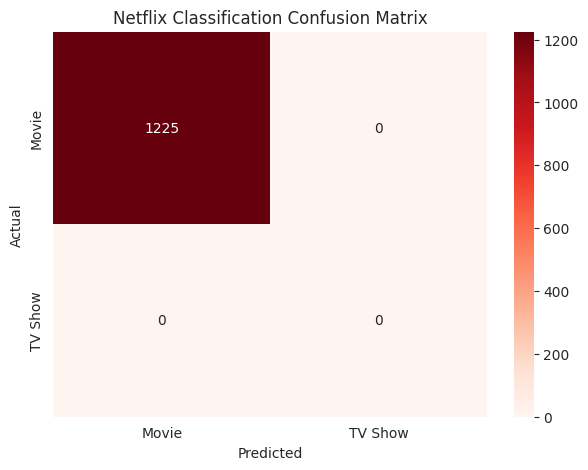

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Movie", "TV Show"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Movie", "TV Show"],
    yticklabels=["Movie", "TV Show"]
)

plt.title("Netflix Classification Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

content_filter = widgets.Dropdown(
    options=["All", "Movie", "TV Show"],
    value="All",
    description="Content:"
)

year_filter = widgets.IntRangeSlider(
    value=[
        int(df["release_year"].min()),
        int(df["release_year"].max())
    ],
    min=int(df["release_year"].min()),
    max=int(df["release_year"].max()),
    step=1,
    description="Year:",
    continuous_update=False,
    layout=widgets.Layout(width="80%")
)

output = widgets.Output()

def update_dashboard(change=None):

    with output:
        clear_output(wait=True)

        filtered = df[
            df["release_year"].between(
                year_filter.value[0],
                year_filter.value[1]
            )
        ].copy()

        if content_filter.value != "All":
            filtered = filtered[
                filtered["type"] == content_filter.value
            ]

        print("NETFLIX BUSINESS INSIGHTS DASHBOARD")
        print("=" * 45)

        print("Total Titles:", len(filtered))

        print("Movies:", (filtered["type"] == "Movie").sum())

        print("TV Shows:", (filtered["type"] == "TV Show").sum())

        if filtered.empty:
            print("No records available for this selection.")
            return

        yearly = (
            filtered.groupby("release_year")
            .size()
            .reset_index(name="Titles")
        )

        fig1 = px.line(
            yearly,
            x="release_year",
            y="Titles",
            markers=True,
            title="Content Release Trend"
        )

        fig1.show()

        genre_filtered = filtered.assign(
            genre=filtered["listed_in"].str.split(", ")
        ).explode("genre")

        top = (
            genre_filtered["genre"]
            .value_counts()
            .head(10)
            .reset_index()
        )

        top.columns = ["Genre", "Count"]

        fig2 = px.bar(
            top,
            x="Genre",
            y="Count",
            title="Top Genres",
            color="Count",
            color_continuous_scale="Reds"
        )

        fig2.show()

content_filter.observe(update_dashboard, names="value")

year_filter.observe(update_dashboard, names="value")

display(
    widgets.VBox([
        content_filter,
        year_filter,
        output
    ])
)

update_dashboard()

In [ ]:
movie_count = (df["type"] == "Movie").sum()

tv_count = (df["type"] == "TV Show").sum()

movie_percentage = movie_count / len(df) * 100

tv_percentage = tv_count / len(df) * 100

latest_year = int(df["release_year"].max())

oldest_year = int(df["release_year"].min())

print("=" * 60)
print("       NETFLIX BUSINESS INSIGHTS")
print("=" * 60)

print(f"\n1. Total Titles: {len(df)}")

print(
    f"\n2. Movies represent {movie_percentage:.2f}% "
    f"of the dataset."
)

print(
    f"\n3. TV Shows represent {tv_percentage:.2f}% "
    f"of the dataset."
)

print(
    f"\n4. Dataset release-year range: "
    f"{oldest_year} to {latest_year}."
)

print("\n5. Top 5 Genres:")

display(top_genres.head())

print("\n6. Top 5 Countries:")

display(top_countries.head())

print("\n7. Most Common Content Rating:")

print(df["rating"].mode().iloc[0])

print("\nAnalysis Completed!")

       NETFLIX BUSINESS INSIGHTS

1. Total Titles: 8790

2. Movies represent 69.69% of the dataset.

3. TV Shows represent 0.00% of the dataset.

4. Dataset release-year range: 1925 to 2021.

5. Top 5 Genres:


,Genre,Count
0,International Movies,2752
1,Dramas,2426
2,Comedies,1674
3,International TV Shows,1349
4,Documentaries,869



6. Top 5 Countries:


,Country,Titles
0,United States,3240
1,India,1057
2,United Kingdom,638
3,Pakistan,421
4,Not Given,287



7. Most Common Content Rating:
TV-MA

Analysis Completed!


In [ ]:
import plotly.express as px

# Save cleaned dataset
df.to_csv("netflix_final_cleaned.csv", index=False)

# Save yearly analysis
yearly_content.to_csv(
    "netflix_yearly_analysis.csv",
    index=False
)

# Save genre analysis
top_genres.to_csv(
    "netflix_top_genres.csv",
    index=False
)

# Save country analysis
top_countries.to_csv(
    "netflix_top_countries.csv",
    index=False
)

# Save ML model
joblib.dump(
    model,
    "netflix_business_classification_model.pkl"
)

# Save evaluation metrics
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics.to_csv(
    "netflix_model_metrics.csv",
    index=False
)

# Recreate fig1 globally to avoid NameError
yearly_titles = df.groupby("release_year").size().reset_index(name="Titles")
fig1 = px.line(
    yearly_titles,
    x="release_year",
    y="Titles",
    markers=True,
    title="Content Release Trend"
)

# Export interactive chart
fig1.write_html("netflix_trend_dashboard.html")

print("All project files exported successfully!")

All project files exported successfully!
